# Sparsity for extreme value

Testing DAMEX with smaller dataset...
Generating 5,000 samples in 20 dimensions
Normal samples: 4,500 (90.0%)
Extreme samples: 500 (10.0%)

Generating normal data...
Normal data: All values between 1.5 and 3.5

Generating extreme data...
Extreme cone dimension probabilities:
  Dimension 1: 43.8%
  Dimension 2: 21.9%
  Dimension 3: 14.6%
  Dimension 4: 10.9%
  Dimension 5: 8.8%

Verification:
  Actual normal samples: 4,500
  Actual extreme samples: 500

Fitting DAMEX algorithm...
  Parameters: epsilon=0.5, p=0.1
  Selected 501 extreme points (top 10.0%, threshold=96.173)

Test results:
  Found 264 cones
  Top cone: (np.int64(6),) with mass 0.0379

RUNNING FULL ANALYSIS
DAMEX ALGORITHM DEMONSTRATION
Replicating Goix et al. (2017) Figure 5

1. Generating synthetic data...
   Samples: 50,000, Dimensions: 50
   Expected: 10% extremes (low-dimensional), 90% normals (high-dimensional)
Generating 50,000 samples in 50 dimensions
Normal samples: 45,000 (90.0%)
Extreme samples: 5,000 (10.0%)

Gen

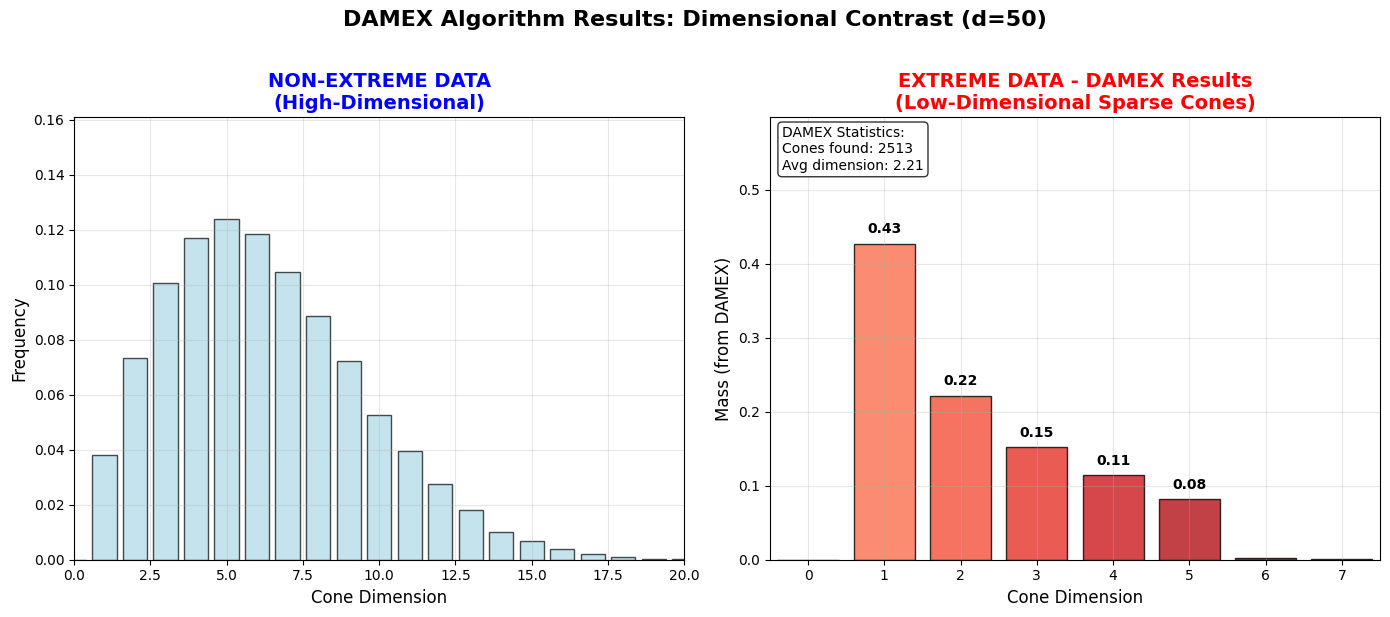


DAMEX ALGORITHM SUMMARY

Key findings:
1. Extreme data is LOW-DIMENSIONAL (sparse):
   - Dimension 1: 0.427 mass
   - Dimension 2: 0.222 mass
   - Dimension 3: 0.152 mass
   - Dimension 4: 0.114 mass
   - Dimension 5: 0.081 mass

2. Non-extreme data is HIGH-DIMENSIONAL (dense):

3. DAMEX discovered 2513 sparse cones
   Top cone: (np.int64(32),) (dim 1)
   with mass: 0.0120

4. Pattern verification:
   Decreasing frequency in extremes: YES
   Pattern: dim1(0.43) > dim2(0.22) > ...

ANALYSIS COMPLETE


In [5]:
import numpy as np
from scipy.stats import rankdata
import matplotlib.pyplot as plt

# ============================================================================
# MAIN EXECUTION WITH DAMEX
# ============================================================================

def main():
    """Run complete DAMEX analysis"""
    print("DAMEX ALGORITHM DEMONSTRATION")
    print("Replicating Goix et al. (2017) Figure 5")
    print("="*70)
    
    # Parameters
    n = 50000
    d = 50
    
    # 1. Generate data
    print(f"\n1. Generating synthetic data...")
    print(f"   Samples: {n:,}, Dimensions: {d}")
    print(f"   Expected: 10% extremes (low-dimensional), 90% normals (high-dimensional)")
    
    X, _, labels = generate_paper_like_data_fixed(n=n, d=d, extreme_ratio=0.1)
    
    # 2. Run DAMEX analysis
    analysis = analyze_with_damex(X, d=d)
    
    # 3. Visualize results
    plot_damex_results(analysis, d=d)
    
    print(f"\n{'='*70}")
    print("ANALYSIS COMPLETE")
    print(f"{'='*70}")
    
    return analysis

# ============================================================================
# ADD DAMEX ANALYSIS FUNCTION
# ============================================================================

def analyze_with_damex(X, d=50):
    """
    Complete analysis using DAMEX algorithm
    """
    n_samples = len(X)
    
    print(f"\n{'='*70}")
    print("ANALYSIS USING DAMEX ALGORITHM")
    print(f"{'='*70}")
    
    # ===== 1. FIT DAMEX ON FULL DATA =====
    print("\n1. Fitting DAMEX on full dataset...")
    dam = DAMEX(epsilon=0.5, p=0.1)
    dam.fit(X)
    
    # Get extreme points identified by DAMEX
    extreme_mask = dam.extreme_mask
    X_extreme = X[extreme_mask]
    X_normal = X[~extreme_mask]
    
    print(f"\n   DAMEX identified:")
    print(f"   - Extreme points: {len(X_extreme):,} ({len(X_extreme)/n_samples*100:.1f}%)")
    print(f"   - Normal points: {len(X_normal):,} ({len(X_normal)/n_samples*100:.1f}%)")
    
    # ===== 2. ANALYZE EXTREME DATA WITH DAMEX =====
    print(f"\n2. Analyzing extreme data (DAMEX results)...")
    
    extreme_dim_dist = dam.get_dimension_distribution()
    total_mass = sum(extreme_dim_dist.values())
    
    print(f"\n   Extreme data dimension distribution (from DAMEX.M_hat):")
    for dim in sorted(extreme_dim_dist.keys()):
        mass = extreme_dim_dist[dim]
        percentage = mass / total_mass * 100
        print(f"     Dimension {dim:2d}: {percentage:6.2f}% (mass: {mass:.4f})")
    
    # ===== 3. ANALYZE NORMAL DATA SIMPLY =====
    print(f"\n3. Analyzing normal data (simple thresholding)...")
    
    # Transform normal data
    V_normal = transform_to_pareto_standalone(X_normal, use_log=True)
    normal_dim_dist = {}
    
    # Use DAMEX's epsilon for consistency
    epsilon = 0.5
    
    for v in V_normal:
        norm_v = np.max(v)
        threshold_v = epsilon * norm_v
        
        # Count features above threshold
        large_features = np.where(v > threshold_v)[0]
        dim = len(large_features)
        
        normal_dim_dist[dim] = normal_dim_dist.get(dim, 0) + 1
    
    total_normal = len(V_normal)
    
    print(f"\n   Normal data dimension distribution:")
    for dim in sorted(normal_dim_dist.keys()):
        count = normal_dim_dist[dim]
        percentage = count / total_normal * 100
        print(f"     Dimension {dim:2d}: {percentage:6.2f}% ({count:5d} samples)")
    
    return {
        'damex': dam,
        'normal': {
            'data': X_normal,
            'dim_dist': normal_dim_dist,
            'total': total_normal
        },
        'extreme': {
            'data': X_extreme,
            'dim_dist': extreme_dim_dist,
            'total': len(X_extreme),
            'total_mass': total_mass
        }
    }

# ============================================================================
# ADD DAMEX CLASS
# ============================================================================

class DAMEX:
    """
    DAMEX algorithm from Goix et al. (2017)
    """
    def __init__(self, epsilon=0.5, k=None, p=0.1):
        self.epsilon = epsilon
        self.k = k
        self.p = p
        self.cones = []
        self.M_hat = {}
        self.sorted_features = []
        
    def transform_to_pareto(self, X):
        n, d = X.shape
        V = np.zeros_like(X)
        self.sorted_features = []
        
        for j in range(d):
            x_sorted = np.sort(X[:, j])
            self.sorted_features.append(x_sorted)
            
            ranks = rankdata(X[:, j], method='average')
            V[:, j] = (n + 1) / (n + 1 - ranks)
        
        return V
    
    def get_extreme_points(self, V):
        n = len(V)
        
        norms = np.max(V, axis=1)
        
        if self.k is None:
            self.k = int(np.sqrt(n))
        
        threshold = np.percentile(norms, 100 * (1 - self.p))
        extreme_mask = norms >= threshold
        extreme_points = V[extreme_mask]
        
        print(f"  Selected {len(extreme_points)} extreme points "
              f"(top {self.p*100:.1f}%, threshold={threshold:.3f})")
        
        return extreme_points, extreme_mask
    
    def identify_cones(self, V_extreme):
        n_extreme, d = V_extreme.shape
        cones_dict = {}
        
        for i, v in enumerate(V_extreme):
            norm_v = np.max(v)
            threshold_v = self.epsilon * norm_v
            
            large_features = np.where(v > threshold_v)[0]
            
            if len(large_features) > 0:
                cone = tuple(sorted(large_features))
                cones_dict[cone] = cones_dict.get(cone, 0) + 1
        
        total_mass = sum(cones_dict.values())
        M_hat = {cone: count/total_mass for cone, count in cones_dict.items()}
        
        return M_hat, cones_dict
    
    def fit(self, X):
        print("\nFitting DAMEX algorithm...")
        print(f"  Parameters: epsilon={self.epsilon}, p={self.p}")
        
        V = self.transform_to_pareto(X)
        V_extreme, extreme_mask = self.get_extreme_points(V)
        self.M_hat, cones_dict = self.identify_cones(V_extreme)
        
        self.cones = sorted(self.M_hat.items(), key=lambda x: x[1], reverse=True)
        self.V = V
        self.V_extreme = V_extreme
        self.extreme_mask = extreme_mask
        
        return self
    
    def get_dimension_distribution(self):
        dim_dist = {}
        total_mass = 0
        
        for cone, mass in self.M_hat.items():
            dim = len(cone)
            dim_dist[dim] = dim_dist.get(dim, 0) + mass
            total_mass += mass
        
        return dim_dist

def generate_paper_like_data_fixed(n=10000, d=50, extreme_ratio=0.1):
    """
    FIXED data generation with proper extreme values
    """
    np.random.seed(42)
    
    n_extreme = int(n * extreme_ratio)
    n_normal = n - n_extreme
    
    print(f"Generating {n:,} samples in {d} dimensions")
    print(f"Normal samples: {n_normal:,} ({n_normal/n*100:.1f}%)")
    print(f"Extreme samples: {n_extreme:,} ({n_extreme/n*100:.1f}%)")
    
    # ===== NORMAL DATA: All moderate values =====
    print("\nGenerating normal data...")
    X_normal = np.random.uniform(1.5, 3.5, size=(n_normal, d))
    print("Normal data: All values between 1.5 and 3.5")
    
    # ===== EXTREME DATA: Few dimensions very high =====
    print(f"\nGenerating extreme data...")
    
    max_extreme_dim = min(5, d)
    dim_probs = np.array([1/(i+1) for i in range(max_extreme_dim)])
    dim_probs = dim_probs / dim_probs.sum()
    
    print(f"Extreme cone dimension probabilities:")
    for dim, prob in enumerate(dim_probs, 1):
        print(f"  Dimension {dim}: {prob*100:.1f}%")
    
    X_extreme = np.zeros((n_extreme, d))
    active_cones = []
    
    for i in range(n_extreme):
        # Choose dimension (1-5 with decreasing probability)
        dim = np.random.choice(range(1, max_extreme_dim + 1), p=dim_probs)
        
        # Choose which features are extreme
        extreme_features = np.random.choice(d, size=dim, replace=False)
        extreme_features = tuple(sorted(extreme_features))
        active_cones.append(extreme_features)
        
        # Set extreme features to VERY high values
        extreme_value = 50 + np.random.exponential(20)  # High values
        X_extreme[i, list(extreme_features)] = extreme_value
        
        # Set other features to moderate (not too small)
        other_features = [j for j in range(d) if j not in extreme_features]
        X_extreme[i, other_features] = np.random.uniform(1.5, 3.5, size=len(other_features))
    
    # ===== COMBINE AND SHUFFLE =====
    X = np.vstack([X_normal, X_extreme])
    
    # Create labels for verification
    labels = np.array(['normal'] * n_normal + ['extreme'] * n_extreme)
    
    # Shuffle
    indices = np.random.permutation(n)
    X = X[indices]
    labels = labels[indices]
    
    # Reorder active_cones
    extreme_mask = labels == 'extreme'
    shuffled_extreme_indices = np.where(extreme_mask)[0]
    active_cones_shuffled = [active_cones[i - n_normal] for i in shuffled_extreme_indices 
                            if i >= n_normal]
    
    # Verify
    print(f"\nVerification:")
    print(f"  Actual normal samples: {np.sum(labels == 'normal'):,}")
    print(f"  Actual extreme samples: {np.sum(labels == 'extreme'):,}")
    
    return X, active_cones_shuffled, labels

def transform_to_pareto_standalone(X, use_log=True):
    """
    CORRECT transformation matching the paper
    Returns log-Pareto transformed data
    """
    n, d = X.shape
    V = np.zeros_like(X)
    
    for j in range(d):
        # Get ranks (handles ties properly)
        ranks = rankdata(X[:, j], method='average')
        
        # Transform to Pareto(1) scale
        # P(X > x) = 1/x for Pareto(1)
        # Empirical version: x̂ = (n+1)/(n+1-ranks)
        pareto_values = (n + 1) / (n + 1 - ranks)
        
        if use_log:
            # Take log as in paper's visualization
            V[:, j] = np.log(pareto_values)
        else:
            V[:, j] = pareto_values
    
    return V


def plot_damex_results(analysis, d=50):
    """
    Visualize DAMEX results showing dimensional contrast
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Get data
    normal_dim_dist = analysis['normal']['dim_dist']
    extreme_dim_dist = analysis['extreme']['dim_dist']
    dam = analysis['damex']
    
    # ===== LEFT: NORMAL DATA =====
    dims_normal = list(range(0, d+1))
    freqs_normal = [normal_dim_dist.get(dim, 0) / analysis['normal']['total'] 
                   for dim in dims_normal]
    
    # Create bar plot
    colors_normal = ['lightblue'] * len(dims_normal)
    colors_normal[d] = 'red'  # Highlight full dimension
    
    bars1 = ax1.bar(dims_normal, freqs_normal, color=colors_normal, 
                   alpha=0.7, edgecolor='black', linewidth=1)
    
    # Emphasize dimension 50
    bars1[d].set_linewidth(2)
    bars1[d].set_edgecolor('darkred')
    
    # Annotate
    freq_at_d = freqs_normal[d]
    if freq_at_d > 0:
        ax1.text(d, freq_at_d + 0.01, f'{freq_at_d:.2f}', 
                ha='center', va='bottom', fontsize=12, 
                fontweight='bold', color='darkred')
    
    ax1.set_xlabel('Cone Dimension', fontsize=12)
    ax1.set_ylabel('Frequency', fontsize=12)
    ax1.set_title('NON-EXTREME DATA\n(High-Dimensional)', 
                 fontsize=14, fontweight='bold', color='blue')
    ax1.set_xlim(0, 20)
    ax1.set_ylim(0, max(freqs_normal)*1.3)
    ax1.grid(True, alpha=0.3)
    
    # ===== RIGHT: EXTREME DATA (DAMEX RESULTS) =====
    # Convert mass to frequency for visualization
    max_dim = min(10, max(extreme_dim_dist.keys(), default=0))
    dims_extreme = list(range(0, max_dim+1))
    
    # Get masses and convert to "frequency-like" values
    masses = [extreme_dim_dist.get(dim, 0) for dim in dims_extreme]
    total_mass = sum(masses)
    if total_mass > 0:
        freqs_extreme = [m/total_mass for m in masses]
    else:
        freqs_extreme = [0] * len(dims_extreme)
    
    # Create gradient colors
    colors_extreme = plt.cm.Reds(np.linspace(0.4, 1.0, len(dims_extreme)))
    
    bars2 = ax2.bar(dims_extreme, freqs_extreme, color=colors_extreme,
                   alpha=0.8, edgecolor='black', linewidth=1)
    
    ax2.set_xlabel('Cone Dimension', fontsize=12)
    ax2.set_ylabel('Mass (from DAMEX)', fontsize=12)
    ax2.set_title('EXTREME DATA - DAMEX Results\n(Low-Dimensional Sparse Cones)', 
                 fontsize=14, fontweight='bold', color='red')
    ax2.set_xlim(-0.5, max_dim+0.5)
    ax2.set_ylim(0, max(freqs_extreme)*1.4 if freqs_extreme else 0.3)
    ax2.grid(True, alpha=0.3)
    
    # Annotate significant cones
    for dim in dims_extreme:
        if dim in extreme_dim_dist and extreme_dim_dist[dim] > 0:
            freq = freqs_extreme[dim]
            if freq > 0.05:
                ax2.text(dim, freq + 0.01, f'{freq:.2f}', 
                        ha='center', va='bottom', fontsize=10,
                        fontweight='bold')
    
    # Add DAMEX statistics
    n_cones = len(dam.M_hat)
    avg_dim = sum(len(cone) * mass for cone, mass in dam.M_hat.items())
    
    ax2.text(0.02, 0.98, f'DAMEX Statistics:\n'
                        f'Cones found: {n_cones}\n'
                        f'Avg dimension: {avg_dim:.2f}',
            transform=ax2.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.suptitle(f'DAMEX Algorithm Results: Dimensional Contrast (d={d})', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save figure
    plt.savefig('damex_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print_damex_summary(analysis, d)


def print_damex_summary(analysis, d):
    """Print DAMEX summary"""
    dam = analysis['damex']
    
    print(f"\n{'='*70}")
    print("DAMEX ALGORITHM SUMMARY")
    print(f"{'='*70}")
    
    print(f"\nKey findings:")
    print(f"1. Extreme data is LOW-DIMENSIONAL (sparse):")
    extreme_dim_dist = analysis['extreme']['dim_dist']
    for dim in sorted(extreme_dim_dist.keys()):
        if dim <= 5:
            mass = extreme_dim_dist[dim]
            print(f"   - Dimension {dim}: {mass:.3f} mass")
    
    print(f"\n2. Non-extreme data is HIGH-DIMENSIONAL (dense):")
    normal_dim_dist = analysis['normal']['dim_dist']
    if d in normal_dim_dist:
        freq = normal_dim_dist[d] / analysis['normal']['total']
        print(f"   - Full dimension ({d}): {freq:.1%} of samples")
    
    print(f"\n3. DAMEX discovered {len(dam.M_hat)} sparse cones")
    print(f"   Top cone: {dam.cones[0][0]} (dim {len(dam.cones[0][0])})")
    print(f"   with mass: {dam.cones[0][1]:.4f}")
    
    # Check if DAMEX found the expected pattern
    print(f"\n4. Pattern verification:")
    
    # Check decreasing frequency in extremes
    masses_1_to_5 = [extreme_dim_dist.get(dim, 0) for dim in range(1, 6)]
    if masses_1_to_5:
        total = sum(masses_1_to_5)
        if total > 0:
            freqs = [m/total for m in masses_1_to_5]
            is_decreasing = all(freqs[i] >= freqs[i+1] for i in range(len(freqs)-1))
            
            print(f"   Decreasing frequency in extremes: {'YES' if is_decreasing else 'NO'}")
            if is_decreasing:
                print(f"   Pattern: dim1({freqs[0]:.2f}) > dim2({freqs[1]:.2f}) > ...")
# ============================================================================
# RUN WITH DAMEX
# ============================================================================

if __name__ == "__main__":
    # First, test with smaller data to verify
    print("Testing DAMEX with smaller dataset...")
    
    # Small test
    X_test, _, _ = generate_paper_like_data_fixed(n=5000, d=20, extreme_ratio=0.1)
    
    # Create and fit DAMEX
    dam_test = DAMEX(epsilon=0.5, p=0.1)
    dam_test.fit(X_test)
    
    print(f"\nTest results:")
    print(f"  Found {len(dam_test.M_hat)} cones")
    print(f"  Top cone: {dam_test.cones[0][0]} with mass {dam_test.cones[0][1]:.4f}")
    
    # Now run full analysis
    print(f"\n{'='*70}")
    print("RUNNING FULL ANALYSIS")
    print(f"{'='*70}")
    
    analysis = main()